# K-Means Clustering — Customer Segmentation

This notebook implements the **K-Means clustering** part of the clustering track.

The same preprocessed feature matrix should be used by the other clustering algorithm so that the final comparison is fair.

**Dataset:** `data.csv`

**Required K-Means work:**
- Data loading and audit
- EDA
- Cleaning and preprocessing
- Elbow curve
- K-Means clustering
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index
- PCA 2D cluster visualisation
- Consolidated results
- Standardized model output for later application integration


## Cell 1 — Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

RANDOM_STATE = 42


## Cell 2 — Configuration

Keep shared configuration values here so they can be changed without searching through the notebook.

In [7]:
DATA_PATH = "../../data/clustering/data.csv"
 
ELBOW_MIN_K = 2
ELBOW_MAX_K = 10


## Cell 3 — Load Dataset

In [8]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (2000, 8)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


## Cell 4 — Dataset Audit

In [9]:
print("Data Types:")
display(df.dtypes.to_frame("Data Type"))

print("Missing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("Duplicate Rows:", df.duplicated().sum())

print("Descriptive Statistics:")
display(df.describe(include="all").T)


Data Types:


,Data Type
CustomerID,int64
Gender,str
Age,int64
Annual Income ($),int64
Spending Score (1-100),int64
Profession,str
Work Experience,int64
Family Size,int64


Missing Values:


,Missing Values
CustomerID,0
Gender,0
Age,0
Annual Income ($),0
Spending Score (1-100),0
Profession,35
Work Experience,0
Family Size,0


Duplicate Rows: 0
Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Gender,2000,2,Female,1186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2000.0,NaN,NaN,NaN,48.96,28.429747,0.0,25.0,48.0,73.0,99.0
Annual Income ($),2000.0,NaN,NaN,NaN,110731.8215,45739.536688,0.0,74572.0,110045.0,149092.75,189974.0
Spending Score (1-100),2000.0,NaN,NaN,NaN,50.9625,27.934661,0.0,28.0,50.0,75.0,100.0
Profession,1965,9,Artist,612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Work Experience,2000.0,NaN,NaN,NaN,4.1025,3.922204,0.0,1.0,3.0,7.0,17.0
Family Size,2000.0,NaN,NaN,NaN,3.7685,1.970749,1.0,2.0,4.0,5.0,9.0


## Cell 5 — EDA

The dataset contains customer information including demographic and spending-related attributes.

Inspect the distributions and relationships before deciding which variables should be used for clustering.

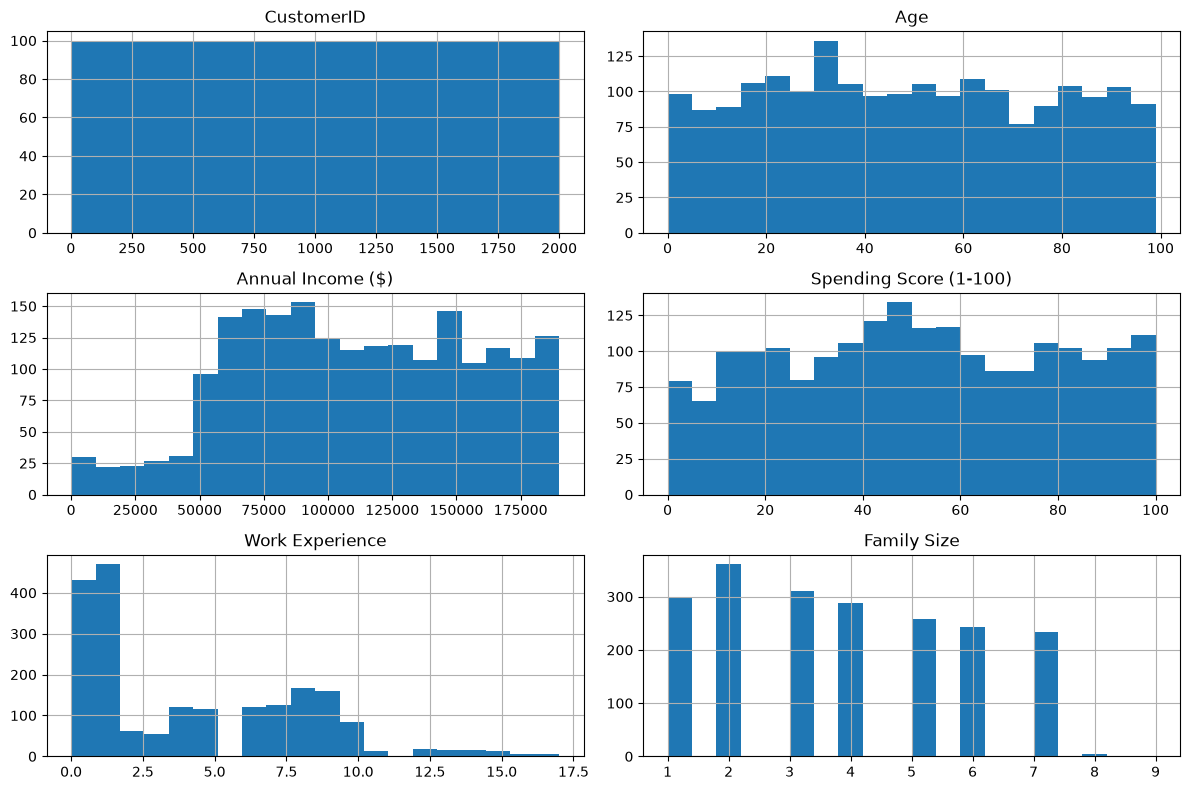

In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()


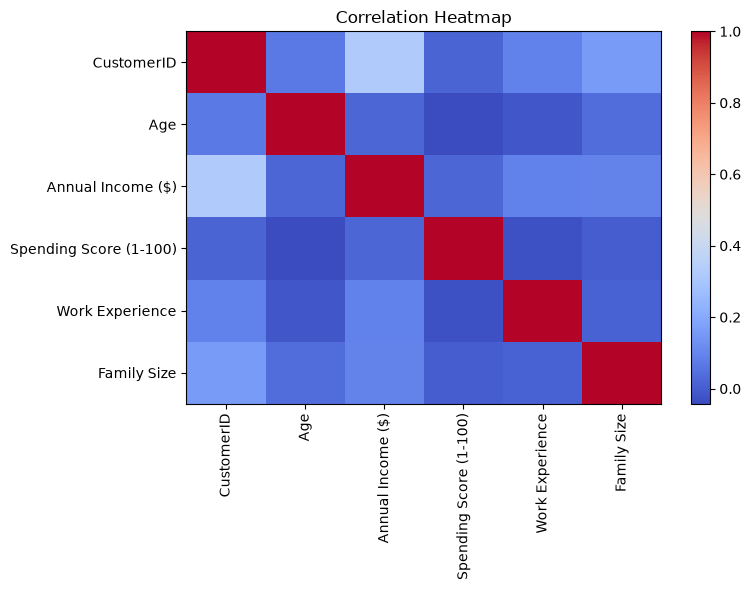

In [11]:
plt.figure(figsize=(8, 6))

correlation_matrix = df[numeric_columns].corr()

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### EDA Observations

Write the team's observations here.

Focus on:
- feature distributions
- possible skewness
- relationships between numerical features
- possible redundant or unsuitable variables
- any unusual values that need attention


## Cell 6 — Data Cleaning

The supplied dataset contains missing values in `Profession`.

Handle missing values and duplicates before constructing the clustering feature matrix.

In [12]:
data = df.copy()

print("Duplicate rows before cleaning:", data.duplicated().sum())

data = data.drop_duplicates().copy()

data["Profession"] = data["Profession"].fillna("Unknown")

print("Duplicate rows after cleaning:", data.duplicated().sum())
print("Missing values after cleaning:")
display(data.isnull().sum().to_frame("Missing Values"))


Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0
Missing values after cleaning:


,Missing Values
CustomerID,0
Gender,0
Age,0
Annual Income ($),0
Spending Score (1-100),0
Profession,0
Work Experience,0
Family Size,0


## Cell 7 — Feature Selection

`CustomerID` is an identifier and should not influence customer similarity.

The remaining demographic, income, spending, work-experience, family-size, gender, and profession variables are used as candidate clustering features.

In [13]:
data = data.drop(columns=["CustomerID"])

categorical_columns = [
    "Gender",
    "Profession"
]

numeric_columns = [
    "Age",
    "Annual Income ($)",
    "Spending Score (1-100)",
    "Work Experience",
    "Family Size"
]

print("Categorical features:", categorical_columns)
print("Numerical features:", numeric_columns)


Categorical features: ['Gender', 'Profession']
Numerical features: ['Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Work Experience', 'Family Size']


## Cell 8 — Feature Engineering

No additional engineered feature is required for the baseline K-Means model.

The original numerical customer attributes are retained, while categorical attributes are encoded in the preprocessing step.

In [14]:
# No additional feature engineering for the baseline K-Means model.


## Cell 9 — Preprocessing

Numerical features are standardized because K-Means is distance-based.

Categorical features are one-hot encoded.

This preprocessing object should also be reused when integrating K-Means into the application.

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ]
)

X = preprocessor.fit_transform(data)

print("Processed feature matrix shape:", X.shape)


Processed feature matrix shape: (2000, 17)


## Cell 10 — Final Feature Matrix

The resulting `X` is the single feature matrix used by K-Means.

There is no train/test split for fitting the clustering model because clustering is unsupervised. Ground-truth labels, if available, must not be used while fitting the clusters.

In [16]:
print("Number of observations:", X.shape[0])
print("Number of processed features:", X.shape[1])
print("Feature matrix type:", type(X).__name__)


Number of observations: 2000
Number of processed features: 17
Feature matrix type: ndarray


## Cell 11 — K-Means: Elbow Method

Run K-Means for several values of `k` and record inertia.

The elbow curve is used to identify a reasonable range for the number of clusters.

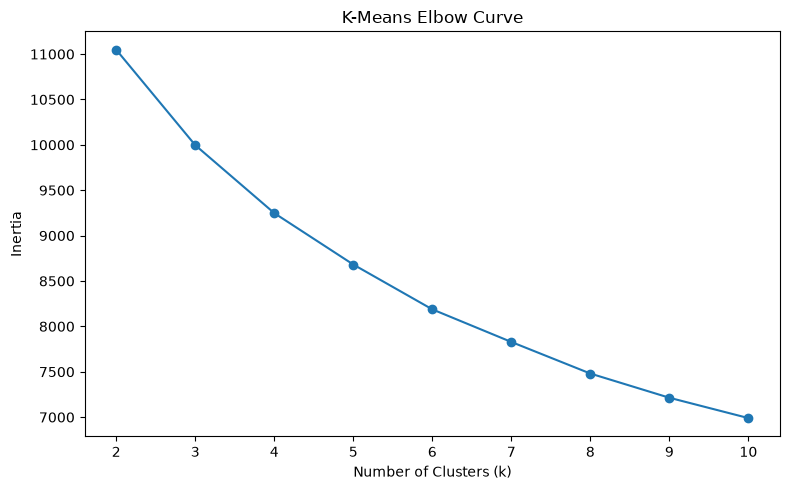

In [17]:
k_values = range(ELBOW_MIN_K, ELBOW_MAX_K + 1)
inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")

plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()


### Elbow Method Observation

Write the team's observation here.

State which value or range of `k` appears reasonable from the elbow curve and why.

## Cell 12 — Select Number of Clusters

Set the final value of `k` after examining the elbow curve.

The value below is only a starting value and should be changed if the team's analysis selects another value.

In [18]:
best_k = 5


## Cell 13 — K-Means Model

Fit the final K-Means model using the selected number of clusters.

In [19]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

print("Number of clusters:", best_k)
print("Cluster counts:")
print(pd.Series(kmeans_labels).value_counts().sort_index())


Number of clusters: 5
Cluster counts:
0    410
1    374
2    415
3    376
4    425
Name: count, dtype: int64


## Cell 14 — K-Means Evaluation

Report all three clustering metrics required by the capstone guidelines.

For these metrics:
- Higher Silhouette Score indicates better separation/cohesion.
- Lower Davies-Bouldin Index indicates better separation.
- Higher Calinski-Harabasz Index indicates better-defined clusters.

In [20]:
kmeans_metrics = {
    "Silhouette Score": silhouette_score(X, kmeans_labels),
    "Davies-Bouldin Index": davies_bouldin_score(X, kmeans_labels),
    "Calinski-Harabasz Index": calinski_harabasz_score(
        X,
        kmeans_labels
    )
}

for metric, value in kmeans_metrics.items():
    print(f"{metric}: {value:.4f}")


Silhouette Score: 0.1120
Davies-Bouldin Index: 1.9599
Calinski-Harabasz Index: 227.2057


## Cell 15 — PCA 2D Visualisation

Reduce the processed feature matrix to two principal components for visualisation only.

The PCA transformation does not replace the feature matrix used to fit K-Means.

In [21]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(X)

pca_data = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": kmeans_labels
})

print(
    "Explained variance by PC1 and PC2:",
    pca.explained_variance_ratio_.sum()
)


Explained variance by PC1 and PC2: 0.34576649331848086


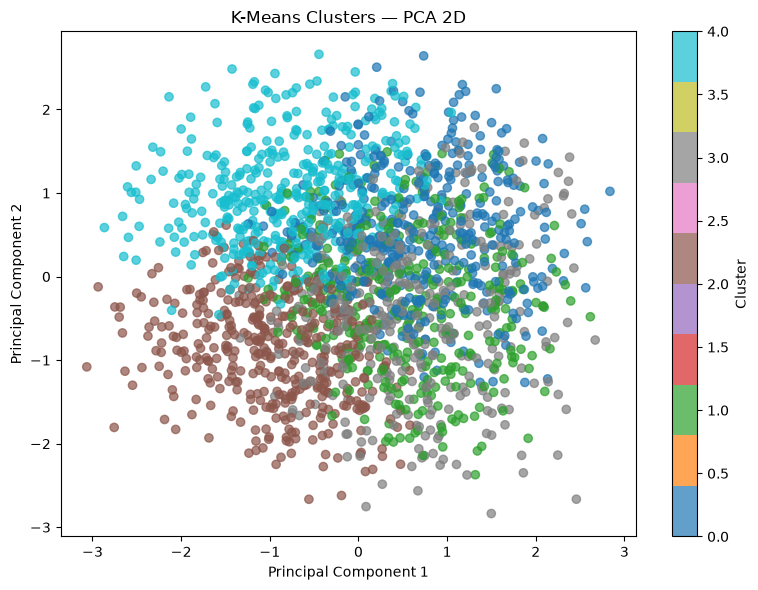

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_data["PC1"],
    pca_data["PC2"],
    c=pca_data["Cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.title("K-Means Clusters — PCA 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.tight_layout()
plt.show()


## Cell 16 — Cluster Analysis

Examine the original customer attributes within each cluster.

Use the cluster labels only after fitting the model to understand what each segment represents.

In [23]:
clustered_data = data.copy()
clustered_data["Cluster"] = kmeans_labels

cluster_summary = clustered_data.groupby("Cluster")[numeric_columns].mean()

display(cluster_summary)


,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
Cluster,,,,,
0,78.148780,122030.841463,60.919512,3.395122,5.348780
1,24.762032,126334.708556,40.657754,3.497326,5.732620
2,33.024096,93930.045783,76.539759,2.122892,2.563855
3,46.718085,131053.010638,50.074468,9.404255,2.789894
4,59.640000,84529.214118,26.235294,2.560000,2.557647


### Cluster Interpretation

Write the team's own interpretation here.

For each cluster, discuss the important characteristics visible in the original customer variables.

Do not make conclusions from the cluster number itself. For example, Cluster 0 has no inherent meaning compared with Cluster 1.

## Cell 17 — Optional t-SNE Visualisation

The capstone guidelines encourage t-SNE but do not require it.

If used, keep it as an additional visualisation and do not use the t-SNE coordinates as the input to K-Means.

In [24]:
# Optional
# from sklearn.manifold import TSNE
#
# tsne = TSNE(
#     n_components=2,
#     random_state=RANDOM_STATE,
#     perplexity=30
# )
#
# X_tsne = tsne.fit_transform(X)
#
# plt.figure(figsize=(8, 6))
# plt.scatter(
#     X_tsne[:, 0],
#     X_tsne[:, 1],
#     c=kmeans_labels,
#     cmap="tab10",
#     alpha=0.7
# )
# plt.title("K-Means Clusters — t-SNE 2D")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.colorbar(label="Cluster")
# plt.tight_layout()
# plt.show()


## Cell 18 — Consolidated Results Table

Create the standard results format so this K-Means result can later be combined with the other clustering algorithm.

In [25]:
results = pd.DataFrame([
    {
        "Algorithm": "K-Means",
        "Clusters": best_k,
        "Configuration": "n_init=10",
        "Silhouette Score": kmeans_metrics["Silhouette Score"],
        "Davies-Bouldin Index": kmeans_metrics["Davies-Bouldin Index"],
        "Calinski-Harabasz Index": kmeans_metrics[
            "Calinski-Harabasz Index"
        ]
    }
])

display(results)


,Algorithm,Clusters,Configuration,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,5,n_init=10,0.112032,1.959923,227.205721


## Cell 19 — Standard Model Output for Application Integration

Keep this structure stable.

When the second clustering algorithm is added later, it should expose equivalent fields so the application can switch between clustering algorithms without changing its interface.

In [26]:
cluster_output = {
    "algorithm": "K-Means",
    "model": kmeans,
    "preprocessor": preprocessor,
    "labels": kmeans_labels,
    "parameters": {
        "n_clusters": best_k,
        "n_init": 10,
        "random_state": RANDOM_STATE
    },
    "metrics": kmeans_metrics,
    "pca_data": pca_data
}

print(cluster_output.keys())


dict_keys(['algorithm', 'model', 'preprocessor', 'labels', 'parameters', 'metrics', 'pca_data'])


## Cell 20 — Final Conclusions

Write the team's conclusions based on the actual results.

Discuss:
- selected number of clusters
- elbow curve
- metric values
- cluster sizes
- characteristics of each customer segment
- PCA visualisation
- limitations of K-Means on this dataset
- what information should eventually be exposed in the application

## Final Notebook Checklist

- [ ] Notebook runs top-to-bottom without errors
- [ ] Dataset audit is included
- [ ] Missing values and duplicates are handled
- [ ] `CustomerID` is excluded from clustering
- [ ] Numerical features are scaled
- [ ] Categorical features are encoded
- [ ] Elbow curve is included
- [ ] Final `k` is justified
- [ ] K-Means labels are generated
- [ ] Silhouette Score is reported
- [ ] Davies-Bouldin Index is reported
- [ ] Calinski-Harabasz Index is reported
- [ ] PCA 2D plot is included
- [ ] Cluster characteristics are analysed
- [ ] Optional t-SNE is included if used
- [ ] Results table is present
- [ ] Standard `cluster_output` structure is present
- [ ] Notebook runs from top to bottom before submission
